# Concept swaps in J-lens coordinates — GPT-2 XL

Replace the model's representation of one concept with another's in J-lens coordinates and
check that the answer changes accordingly, as in the paper's two-hop and flexible-generalization
swaps (`data/experiments/probe-swap.json`, `flexible-generalization.json`). Example:
*"The capital of France is the city of"* with France → China should answer *Beijing*.

**Answer (this run, §3).** J-lens swaps work on GPT-2 XL and are specific: among trials the
model answers correctly, up to 68% of flexible-generalization swaps and up to 47% of two-hop
swaps flip the answer to the swapped concept's, while random directions of the same size stay
at ≤ 8%. Without J (logit-lens directions) swaps fail in early and middle layers; there the
J-lens directions are what carries the concept.

## Method

**Lens vectors.** The J-lens logit of token t at layer l is `u_tᵀ C(γ ⊙ J_l h)/σ` (`u_t`: the
unembedding row; `γ`, `C`: the `ln_f` gain and centering; `σ` is shared by all tokens). Its
direction in the residual stream is `v_t = J_lᵀ C(γ ⊙ u_t)` — a row of `W_U J_l` with the final
norm folded in. The logit-lens control uses `J_l = I`.

**Swap (clamping).** For source s and target t, `V = [v_s v_t]` and coordinates `c = V⁺h`. A
clean pass records `c_clean` at every band layer and position; the patched pass sets, after
each band block, `h ← h + V(c* − V⁺h)` with `c* = c_clean + α(swap(c_clean) − c_clean)`. At
α = 1 the two coordinates are exchanged; the component of h orthogonal to `span(V)` is kept.
All prompt positions except BOS are patched, as in the paper (*"at every token position across
a band of intermediate layers"*).

Clamping matters with a band: applying the swap `h + αV(swap(c) − c)` to the already patched
stream at each layer undoes it at every second layer (the coordinates carried over are
swapped back), and with α > 1 the overshoot compounds.

**Grid.** Bands of block outputs 8–16, 16–24, 24–32, 32–40, 40–47, 12–36, 16–40 (GPT-2 XL has
no published workspace band); α ∈ {1, 2, 4}; directions `J`, `logit`, and `random` (each
position's J-swap update norm in a random direction).

**Success.** The next-token top-1 is a spelling of the swap answer. Reported over all trials
and over trials the model answers correctly without intervention, with Wilson 95% intervals.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "readout_cache.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm

import jlens
from gpt2 import GPT2LensModel
from jlens.evaluation import spelling_ids
from jlens.hooks import ActivationRecorder

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)

In [3]:
MODEL_ID = "openai-community/gpt2-xl"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / "gpt2-xl-convergence"))
LENS_PATH = RUN_DIR / "snapshot_lens_134.pt"
OUT_PATH = RUN_DIR / "swap" / "swap_trials.csv"
BANDS = ["8-16", "16-24", "24-32", "32-40", "40-47", "12-36", "16-40"]  # half-open block-output ranges
ALPHAS = [1.0, 2.0, 4.0]
MODES = ["J", "logit", "random"]
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.manual_seed(0)

## 1. Trials

In [4]:
def load_trials() -> pd.DataFrame:
    trials = []
    for item in json.load(open(Path(REPO_DIR) / "data/experiments/probe-swap.json"))["items"]:
        trials.append({"set": "probe-swap", "group": item["category"], "name": item["name"],
                       "prompt": item["prompt"].rstrip(), "source": item["intermediate"], "target": item["swap_to"],
                       "answer": item["answer"], "swap_answer": item["swap_answer"]})
    for category in json.load(open(Path(REPO_DIR) / "data/experiments/flexible-generalization.json"))["categories"]:
        for func in category["funcs"]:
            for source in category["args"]:
                for target in category["args"]:
                    if target != source:
                        trials.append({
                            "set": "flexible", "group": f"{category['name']}/{func['name']}",
                            "name": f"{func['name']}:{source}->{target}",
                            "prompt": func["template"].format(arg=source).rstrip(), "source": source,
                            "target": target, "answer": func["answers"][source],
                            "swap_answer": func["answers"][target]})
    return pd.DataFrame(trials)


trials = load_trials()
display(trials.groupby("set").size().to_frame("trials"))
trials.groupby("set").head(2)[["set", "prompt", "source", "target", "answer", "swap_answer"]]

,trials
set,
flexible,192
probe-swap,90


,set,prompt,source,target,answer,swap_answer
0,probe-swap,Fact: The language spoken in the country where...,Brazil,Mexico,Portuguese,Spanish
1,probe-swap,Fact: The hard covering on the back of the slo...,turtle,snake,shell,scale
90,flexible,The capital of France is the city of,France,Canada,Paris,Ottawa
91,flexible,The capital of France is the city of,France,China,Paris,Beijing


## 2. Run

Skipped when `OUT_PATH` exists (~10 min on a V100 for 282 trials × 63 settings).

In [5]:
if OUT_PATH.exists():
    results = pd.read_csv(OUT_PATH)
else:
    model = GPT2LensModel.from_pretrained(MODEL_ID, device=DEVICE)
    tok = model.tokenizer
    lens = jlens.JacobianLens.load(str(LENS_PATH))
    W_U = model._lm_head.weight.float()
    gamma = model._final_norm.weight.float()

    def concept_token(word):
        ids = tok.encode(" " + word, add_special_tokens=False)
        return ids[0], len(ids) == 1

    trials["source_id"], trials["source_single"] = zip(*trials.source.map(concept_token), strict=True)
    trials["target_id"], trials["target_single"] = zip(*trials.target.map(concept_token), strict=True)

    bases = {}

    @torch.no_grad()
    def basis(source_id, target_id, layer, mode):
        """V = [v_s v_t] and its pseudoinverse; random mode uses the J basis for the update norm."""
        key = (source_id, target_id, layer, "logit" if mode == "logit" else "J")
        if key not in bases:
            vectors = []
            for token in (source_id, target_id):
                g = gamma * W_U[token]
                g = g - g.mean()
                vectors.append(g if key[3] == "logit" else g @ lens.jacobians[layer].to(DEVICE).float())
            V = torch.stack(vectors, 1)
            bases[key] = (V, torch.linalg.pinv(V))
        return bases[key]

    class Swap:
        """Clamp the (source, target) lens coordinates at every hooked layer to swapped clean values."""

        def __init__(self, layers, source_id, target_id, alpha, mode, clean):
            self.source_id, self.target_id, self.alpha, self.mode, self.clean = (
                source_id, target_id, alpha, mode, clean)
            self.handles = [model.layers[layer].register_forward_hook(self.hook(layer)) for layer in layers]

        def hook(self, layer):
            def fn(module, inputs, output):
                h = output if torch.is_tensor(output) else output[0]
                V, V_pinv = basis(self.source_id, self.target_id, layer, self.mode)
                c = h[0, 1:].float() @ V_pinv.T  # [seq, 2], BOS skipped
                c_clean = self.clean[layer][0, 1:].float() @ V_pinv.T
                target = c_clean + self.alpha * (c_clean[:, [1, 0]] - c_clean)
                update = (target - c) @ V.T
                if self.mode == "random":
                    direction = torch.randn_like(update)
                    update = direction / direction.norm(dim=-1, keepdim=True) * update.norm(dim=-1, keepdim=True)
                h = h.clone()
                h[0, 1:] += update.to(h.dtype)
                return h if torch.is_tensor(output) else (h, *output[1:])
            return fn

        def __enter__(self):
            return self

        def __exit__(self, *exc):
            for handle in self.handles:
                handle.remove()

    answer_ids = {}

    def ids_of(word):
        if word not in answer_ids:
            answer_ids[word] = sorted(spelling_ids(tok, word))
        return answer_ids[word]

    @torch.no_grad()
    def next_token_logits(prompt):
        hidden = model.forward(model.encode(prompt)).last_hidden_state  # ln_f already applied
        return model._lm_head(hidden[0, -1]).float()

    def rank_of(logits, word):
        return int((logits > logits[ids_of(word)].max()).sum()) + 1

    rows = []
    for _, trial in tqdm(trials.iterrows(), total=len(trials), desc="trials"):
        with ActivationRecorder(model.layers, at=range(model.n_layers - 1)) as recorder:
            base = next_token_logits(trial.prompt)
        clean = {layer: activation.detach() for layer, activation in recorder.activations.items()}
        row = trial.drop(["prompt"]).to_dict()
        row.update(base_top1=tok.decode([int(base.argmax())]), base_correct=int(base.argmax()) in ids_of(trial.answer),
                   base_rank_swap=rank_of(base, trial.swap_answer))
        for band in BANDS:
            start, stop = map(int, band.split("-"))
            for mode in MODES:
                for alpha in ALPHAS:
                    with Swap(range(start, stop), trial.source_id, trial.target_id, alpha, mode, clean):
                        patched = next_token_logits(trial.prompt)
                    rows.append({**row, "band": band, "mode": mode, "alpha": alpha,
                                 "top1": tok.decode([int(patched.argmax())]),
                                 "success": int(patched.argmax()) in ids_of(trial.swap_answer),
                                 "rank_swap": rank_of(patched, trial.swap_answer),
                                 "rank_answer": rank_of(patched, trial.answer)})
    results = pd.DataFrame(rows)
    results.to_csv(OUT_PATH, index=False)
    del model
print(len(results), "rows")

17766 rows


## 3. Results

### Baseline: does GPT-2 XL answer without intervention?

In [6]:
base = results.drop_duplicates(["set", "name"])
base.groupby("set").agg(trials=("base_correct", "size"), correct=("base_correct", "sum"),
                        accuracy=("base_correct", "mean")).round(3)

,trials,correct,accuracy
set,,,
flexible,192,63,0.328
probe-swap,90,15,0.167


### Swap success over all trials

In [7]:
def success_table(frame):
    return frame.groupby(["set", "mode", "alpha", "band"]).success.mean().unstack("band")[BANDS].round(3)


success_table(results)

band                      8-16  16-24  24-32  32-40  40-47  12-36  16-40
set        mode   alpha                                                 
flexible   J      1.0    0.068  0.078  0.078  0.146  0.151  0.203  0.208
                  2.0    0.281  0.240  0.203  0.141  0.109  0.208  0.167
                  4.0    0.271  0.266  0.172  0.073  0.026  0.104  0.068
           logit  1.0    0.000  0.000  0.016  0.130  0.135  0.078  0.135
                  2.0    0.000  0.000  0.125  0.109  0.109  0.125  0.109
                  4.0    0.005  0.052  0.109  0.042  0.026  0.052  0.042
           random 1.0    0.005  0.005  0.005  0.000  0.010  0.005  0.016
                  2.0    0.026  0.005  0.005  0.005  0.016  0.021  0.021
                  4.0    0.026  0.031  0.021  0.000  0.010  0.026  0.010
probe-swap J      1.0    0.011  0.011  0.022  0.056  0.022  0.067  0.078
                  2.0    0.078  0.089  0.111  0.089  0.078  0.100  0.111
                  4.0    0.111  0.122  0.100  0.033  0.044  0.056  0.033
           logit  1.0    0.000  0.011  0.011  0.067  0.022  0.022  0.067
                  2.0    0.000  0.011  0.022  0.067  0.067  0.089  0.078
                  4.0    0.011  0.011  0.089  0.033  0.044  0.033  0.033
           random 1.0    0.011  0.022  0.000  0.022  0.011  0.011  0.011
                  2.0    0.011  0.000  0.011  0.011  0.011  0.000  0.000
                  4.0    0.000  0.000  0.022  0.000  0.011  0.000  0.000

### Swap success over baseline-correct trials

Only trials the model answers correctly can show that the swap moves the *computed* answer.
Wilson 95% intervals for the best setting of each direction:

In [8]:
correct = results[results.base_correct]
display(success_table(correct))


def wilson(successes, n, z=1.96):
    p = successes / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centre - half, centre + half


grouped = correct.groupby(["set", "mode", "alpha", "band"]).success.agg(["sum", "size"]).reset_index()
best = grouped.loc[grouped.groupby(["set", "mode"])["sum"].idxmax()].copy()
best["rate"] = best["sum"] / best["size"]
best["CI lo"], best["CI hi"] = wilson(best["sum"], best["size"])
best.round(3)

band                      8-16  16-24  24-32  32-40  40-47  12-36  16-40
set        mode   alpha                                                 
flexible   J      1.0    0.175  0.206  0.222  0.397  0.413  0.492  0.508
                  2.0    0.683  0.571  0.508  0.349  0.254  0.476  0.397
                  4.0    0.603  0.603  0.397  0.127  0.079  0.206  0.127
           logit  1.0    0.000  0.000  0.048  0.365  0.365  0.222  0.381
                  2.0    0.000  0.000  0.333  0.302  0.238  0.349  0.302
                  4.0    0.016  0.111  0.302  0.111  0.079  0.143  0.127
           random 1.0    0.000  0.000  0.016  0.000  0.016  0.000  0.016
                  2.0    0.048  0.016  0.016  0.000  0.016  0.048  0.032
                  4.0    0.063  0.079  0.048  0.000  0.016  0.048  0.032
probe-swap J      1.0    0.000  0.000  0.067  0.200  0.067  0.267  0.333
                  2.0    0.333  0.333  0.333  0.267  0.133  0.333  0.333
                  4.0    0.333  0.467  0.333  0.067  0.067  0.200  0.067
           logit  1.0    0.000  0.000  0.000  0.200  0.067  0.067  0.200
                  2.0    0.000  0.000  0.067  0.200  0.133  0.333  0.200
                  4.0    0.000  0.000  0.200  0.067  0.067  0.067  0.067
           random 1.0    0.000  0.000  0.000  0.000  0.000  0.000  0.000
                  2.0    0.000  0.000  0.000  0.000  0.000  0.000  0.000
                  4.0    0.000  0.000  0.000  0.000  0.000  0.000  0.000

,set,mode,alpha,band,sum,size,rate,CI lo,CI hi
13,flexible,J,2.0,8-16,43,63,0.683,0.560,0.784
23,flexible,logit,1.0,16-40,24,63,0.381,0.271,0.504
57,flexible,random,4.0,16-24,5,63,0.079,0.034,0.173
78,probe-swap,J,4.0,16-24,7,15,0.467,0.248,0.699
91,probe-swap,logit,2.0,12-36,5,15,0.333,0.152,0.583
105,probe-swap,random,1.0,12-36,0,15,0.000,-0.000,0.204


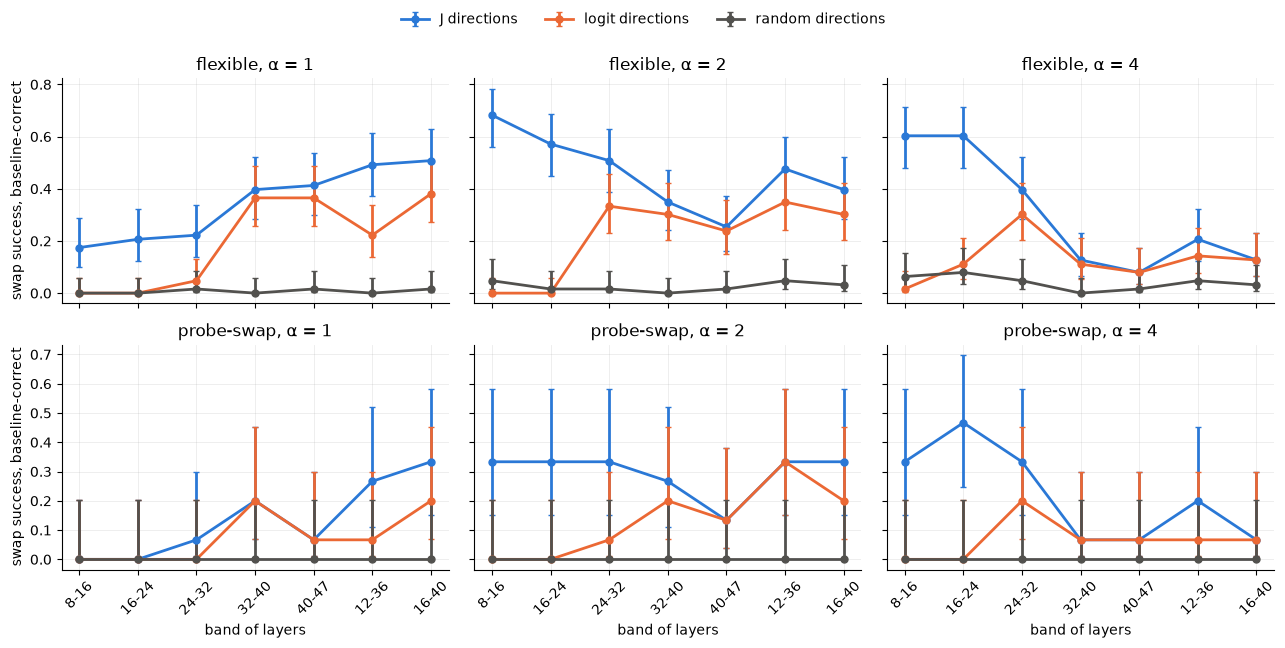

In [9]:
COLORS = {"J": "#2a78d6", "logit": "#eb6834", "random": "#52514e"}
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True, sharey="row")
for row_axes, name in zip(axes, ("flexible", "probe-swap"), strict=True):
    for ax, alpha in zip(row_axes, ALPHAS, strict=True):
        for mode, color in COLORS.items():
            sub = grouped[(grouped.set == name) & (grouped["mode"] == mode) & (grouped.alpha == alpha)]
            sub = sub.set_index("band").loc[BANDS]
            rate = sub["sum"] / sub["size"]
            lo, hi = wilson(sub["sum"], sub["size"])
            ax.errorbar(range(len(BANDS)), rate, yerr=[rate - lo, hi - rate], color=color, marker="o", ms=5,
                        lw=2, capsize=2, label=f"{mode} directions")
        ax.set_title(f"{name}, α = {alpha:g}")
        ax.grid(alpha=0.25, lw=0.6)
        ax.spines[["top", "right"]].set_visible(False)
    row_axes[0].set_ylabel("swap success, baseline-correct")
for ax in axes[-1]:
    ax.set_xticks(range(len(BANDS)), BANDS, rotation=45)
    ax.set_xlabel("band of layers")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

### Median log10 rank gain of the swap answer (all trials)

In [10]:
results["log10 rank gain"] = np.log10(results.base_rank_swap) - np.log10(results.rank_swap)
results.groupby(["set", "mode", "alpha", "band"])["log10 rank gain"].median().unstack("band")[BANDS].round(2)

band                     8-16  16-24  24-32  32-40  40-47  12-36  16-40
set        mode   alpha                                                
flexible   J      1.0    0.23   0.22   0.17   0.25   0.30   0.31   0.30
                  2.0    0.47   0.41   0.31   0.33   0.40   0.48   0.45
                  4.0    0.60   0.49   0.48   0.31   0.37   0.42   0.35
           logit  1.0    0.00   0.00   0.08   0.19   0.27   0.13   0.18
                  2.0    0.00   0.01   0.14   0.30   0.37   0.23   0.29
                  4.0    0.01   0.05   0.21   0.30   0.38   0.27   0.27
           random 1.0    0.00   0.00   0.01   0.00  -0.02   0.03   0.00
                  2.0    0.07   0.06   0.01  -0.10  -0.20   0.08  -0.03
                  4.0    0.04   0.06   0.02  -0.31  -0.45  -0.43  -0.48
probe-swap J      1.0    0.02   0.02   0.04   0.06   0.04   0.07   0.04
                  2.0    0.07   0.07   0.07   0.11   0.11   0.12   0.08
                  4.0    0.13   0.14   0.10   0.11   0.18   0.15   0.10
           logit  1.0    0.00   0.00   0.04   0.06   0.06   0.07   0.07
                  2.0    0.00   0.01   0.08   0.12   0.12   0.12   0.12
                  4.0    0.00   0.03   0.10   0.16   0.20   0.12   0.14
           random 1.0    0.00   0.00   0.01   0.00   0.00   0.00   0.03
                  2.0    0.01   0.02   0.00  -0.02  -0.02   0.02  -0.03
                  4.0    0.01   0.00   0.00  -0.07  -0.11  -0.15  -0.23

## 4. Conclusions

* **J-lens swaps move the computed answer.** Among baseline-correct trials, the best setting
  flips 68% of flexible-generalization trials (α = 2, band 8–16) and 47% of two-hop trials
  (α = 4, band 16–24; only 15 such trials). With α = 1 the wide bands 12–36 and 16–40 reach
  ~50%. Over all trials the flexible success is ~20–28%; the paper reports 76/192 at α = 1 and
  101/192 at α = 2 for much larger models.
* **Specific to the lens directions.** Random directions with the same per-position update norm
  succeed in ≤ 8% of baseline-correct trials.
* **J matters in early and middle layers.** Logit-lens directions fail at bands 8–16 and 16–24
  (0% at α ≤ 2, ≤ 11% at α = 4) and only catch up from layer ~32 on, where `J_l` is close to the identity.
* **Strength vs depth.** Early bands need α = 2–4; late bands work best at α = 1 and degrade
  with larger α.
* **Caveats.** GPT-2 XL answers only 33% of flexible and 17% of two-hop prompts correctly, so
  the baseline-correct sets are small (63 and 15 trials); bands were chosen as a grid, not
  from a measured workspace band.